<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
df = pd.read_csv("Housing.csv")  # Adjust file path if needed
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [9]:
print(df.shape)
print(df.info())


(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


In [10]:
df = df.drop("Address", axis=1)
df = df.dropna()


single lr

In [11]:
X = df[["Avg. Area Income"]].values  # single feature
y = df["Price"].values               # target


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
sv_lr = LinearRegression()
sv_lr.fit(X_train, y_train)


LinearRegression()

In [14]:
y_pred = sv_lr.predict(X_test)

print("Coefficients:", sv_lr.coef_)
print("Intercept:", sv_lr.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Coefficients: [21.20890629]
Intercept: -225053.70287170145
RMSE: 272387.38417676394
R2 Score: 0.39694865192619766


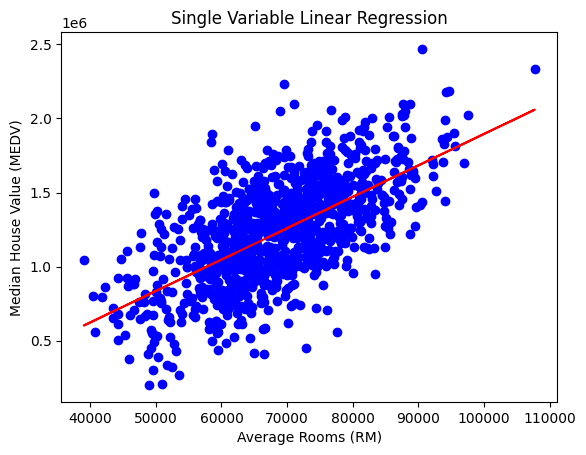

In [15]:
plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, y_pred, color="red")
plt.xlabel("Average Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Single Variable Linear Regression")
plt.show()


In [17]:
X_multi = df.drop("Price", axis=1).values
y_multi = df["Price"].values


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)


In [19]:
mv_lr = LinearRegression()
mv_lr.fit(X_train, y_train)


LinearRegression()

In [20]:
y_pred = mv_lr.predict(X_test)

print("Coefficients:", mv_lr.coef_)
print("Intercept:", mv_lr.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Coefficients: [2.16522058e+01 1.64666481e+05 1.19624012e+05 2.44037761e+03
 1.52703134e+01]
Intercept: -2635072.900931217
RMSE: 100444.06055556827
R2 Score: 0.9179971706834602


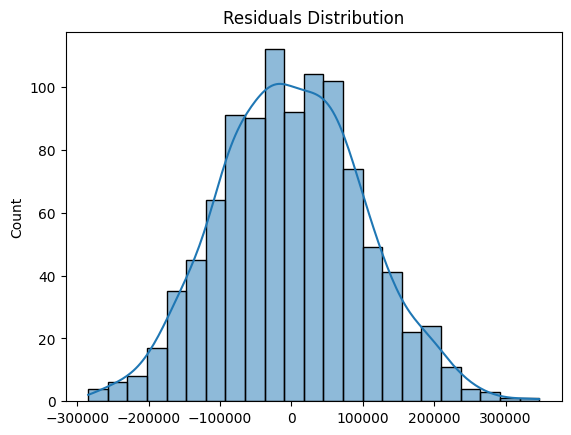

In [21]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()
